<a href="https://colab.research.google.com/github/fariya09ahmed-commits/Fariya-Ahmed/blob/main/assg_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
df = pd.read_csv('/content/drive/MyDrive/heart datas.csv')
print("✅ Dataset loaded successfully!")
print(f"\n📊 Dataset Shape: {df.shape}")

✅ Dataset loaded successfully!

📊 Dataset Shape: (1025, 14)


📋 First 5 Patients:
📊 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
📈 Statistical Summary:
target
1    526
0    499
Name: count, dtype: int64


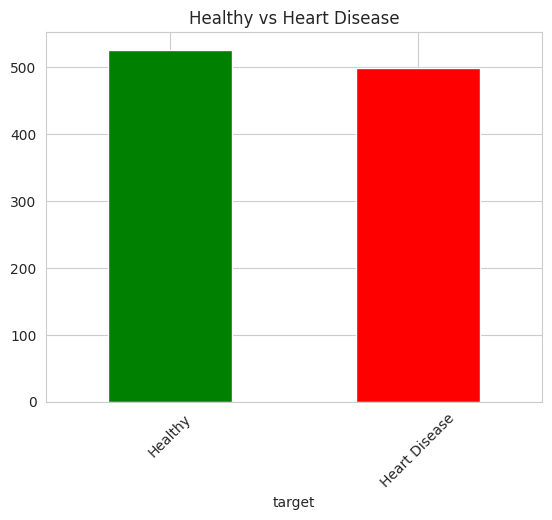

In [9]:
# View first 5 rows
print("📋 First 5 Patients:")
df.head()
# Dataset information
print("📊 Dataset Information:")
df.info()
# Statistical summary
print("📈 Statistical Summary:")
df.describe().T
# Show distribution
print(df['target'].value_counts())

# Plot
df['target'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Healthy vs Heart Disease')
plt.xticks([0, 1], ['Healthy', 'Heart Disease'], rotation=45)
plt.show()

## Data preparation

In [10]:
# Separate Features (X) and Target (y)
X = df.drop('target', axis=1)  # All columns except target
y = df['target']  # Only the target column

print("✅ Features (X):")
print(f"   Shape: {X.shape}")
print(f"   Columns: {X.columns.tolist()}")

print("\n✅ Target (y):")
print(f"   Shape: {y.shape}")
print(f"   Values: 0 (Healthy) and 1 (Heart Disease)")

✅ Features (X):
   Shape: (1025, 13)
   Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

✅ Target (y):
   Shape: (1025,)
   Values: 0 (Healthy) and 1 (Heart Disease)


In [27]:
# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=20
)

print("✅ Data Split:")
print(f"   Training: {X_train.shape[0]} patients ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"   Testing:  {X_test.shape[0]} patients ({X_test.shape[0]/len(df)*100:.0f}%)")

✅ Data Split:
   Training: 615 patients (60%)
   Testing:  410 patients (40%)


In [28]:
# Feature Scaling (IMPORTANT for KNN!)
print("⚙️ Scaling features...\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")

⚙️ Scaling features...

✅ Feature scaling completed!


## k-Nearest Neighbors (KNN)

Best K: 1


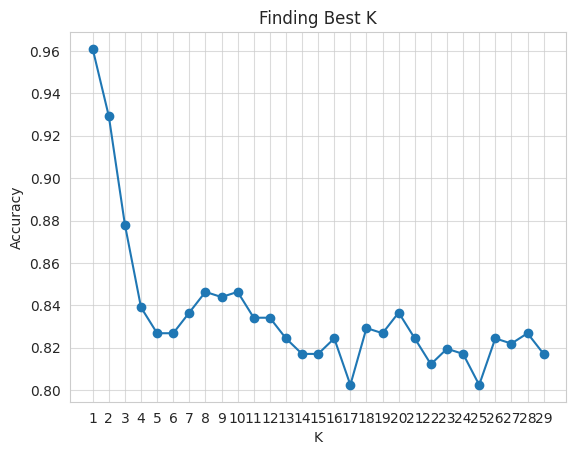

In [29]:
# Find best K
accuracies = []
for k in range(1,30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = accuracies.index(max(accuracies)) + 1
print(f"Best K: {best_k}")

# Plot
plt.plot(range(1, 30), accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(range(1, 30))
plt.title('Finding Best K')
plt.grid(alpha=0.7)

plt.show()

In [30]:
# Train final KNN model
print(f"\n🤖 Training KNN with K = {best_k}...\n")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("✅ KNN Model trained!")
print(f"\n📊 KNN Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")


🤖 Training KNN with K = 1...

✅ KNN Model trained!

📊 KNN Accuracy: 0.9610 (96.10%)



📋 KNN Classification Report:
               precision    recall  f1-score   support

      Healthy       0.97      0.95      0.96       206
Heart Disease       0.95      0.97      0.96       204

     accuracy                           0.96       410
    macro avg       0.96      0.96      0.96       410
 weighted avg       0.96      0.96      0.96       410



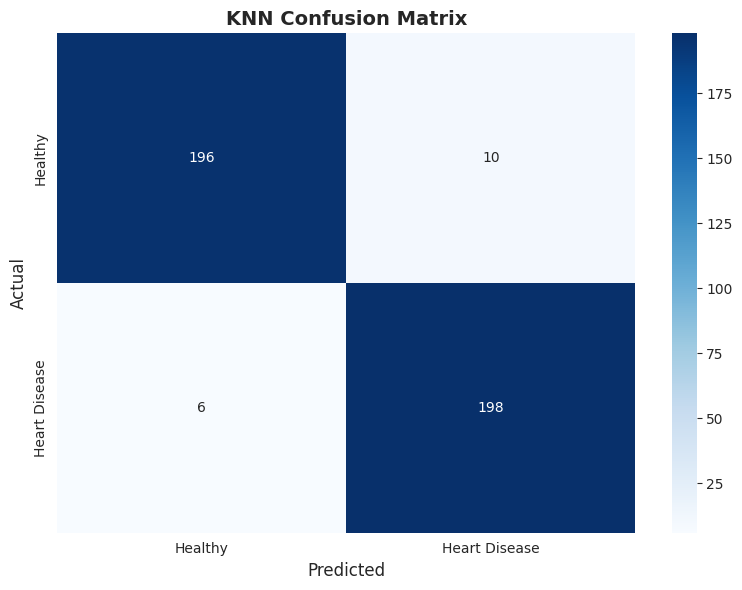

In [31]:
# Evaluation
print("\n📋 KNN Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_knn, target_names=['Healthy', 'Heart Disease']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])
plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)

## Decision Tree

In [41]:
# Train Decision Tree
print("🌳 Training Decision Tree...\n")

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=8,          # Limit depth to avoid overfitting
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)  # No scaling needed
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("✅ Decision Tree trained!")
print(f"\n📊 Decision Tree Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")

🌳 Training Decision Tree...

✅ Decision Tree trained!

📊 Decision Tree Accuracy: 0.8634 (86.34%)



📋 Decision Tree Classification Report:
               precision    recall  f1-score   support

      Healthy       0.91      0.81      0.86       206
Heart Disease       0.83      0.92      0.87       204

     accuracy                           0.86       410
    macro avg       0.87      0.86      0.86       410
 weighted avg       0.87      0.86      0.86       410



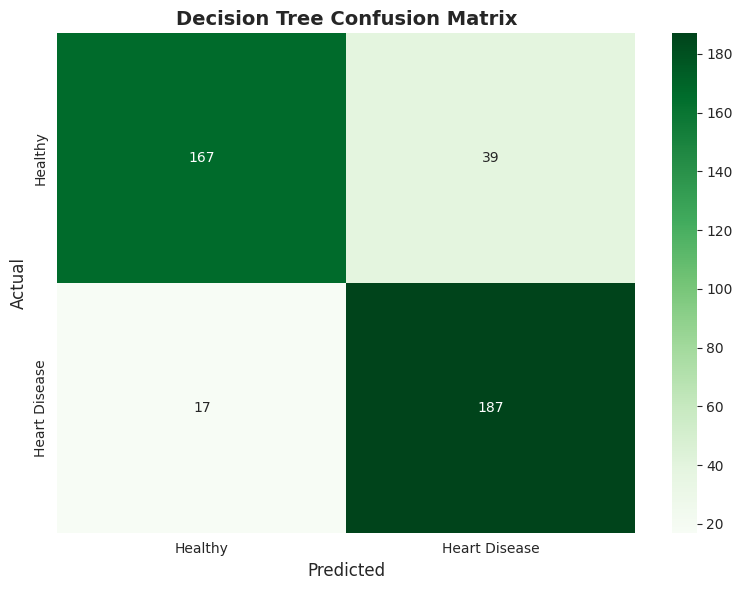

In [44]:
# Evaluation
print("\n📋 Decision Tree Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=['Healthy', 'Heart Disease']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)


⭐ Feature Importance (Decision Tree):
 Feature  Importance
      cp    0.348298
    thal    0.188363
      ca    0.163856
     age    0.072389
 thalach    0.064824
    chol    0.058711
 oldpeak    0.051833
     sex    0.033059
trestbps    0.016402
 restecg    0.001670
   exang    0.000595
     fbs    0.000000
   slope    0.000000


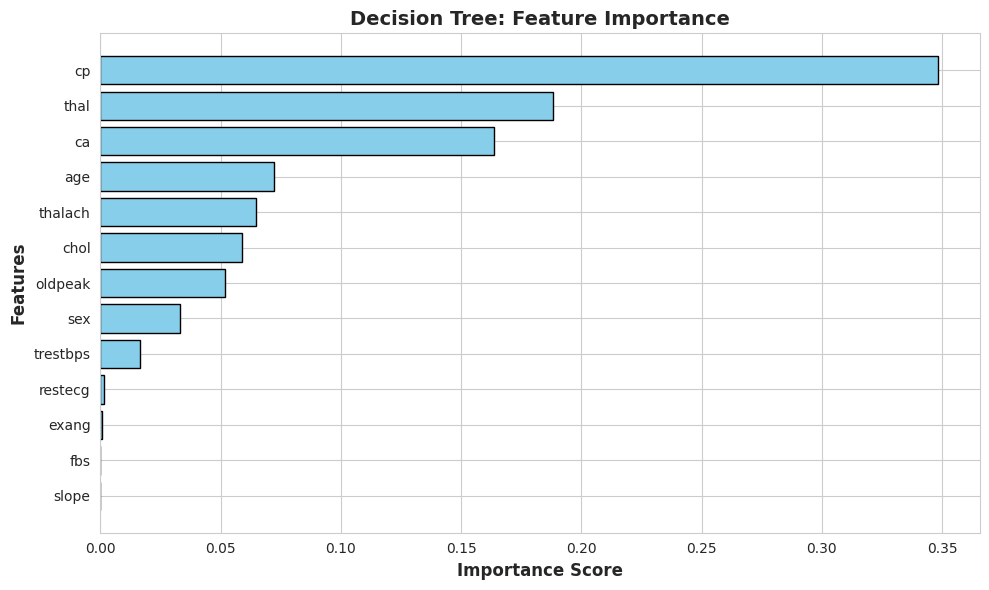


💡 These features are most important for prediction!



In [45]:
# Feature Importance
print("\n⭐ Feature Importance (Decision Tree):")
print("=" * 60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='skyblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Decision Tree: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 These features are most important for prediction!")
print("\n" + "="*60)

## Random Forest

In [51]:
# Train Random Forest
print("🌲🌳🌲 Training Random Forest...\n")

rf_model = RandomForestClassifier(
    n_estimators=120,     # 100 trees
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("✅ Random Forest trained!")
print(f"   → {rf_model.n_estimators} trees created")
print(f"   → Each tree votes")
print(f"\n📊 Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

🌲🌳🌲 Training Random Forest...

✅ Random Forest trained!
   → 120 trees created
   → Each tree votes

📊 Random Forest Accuracy: 0.8463 (84.63%)



📋 Random Forest Classification Report:
               precision    recall  f1-score   support

      Healthy       0.89      0.79      0.84       206
Heart Disease       0.81      0.90      0.85       204

     accuracy                           0.85       410
    macro avg       0.85      0.85      0.85       410
 weighted avg       0.85      0.85      0.85       410



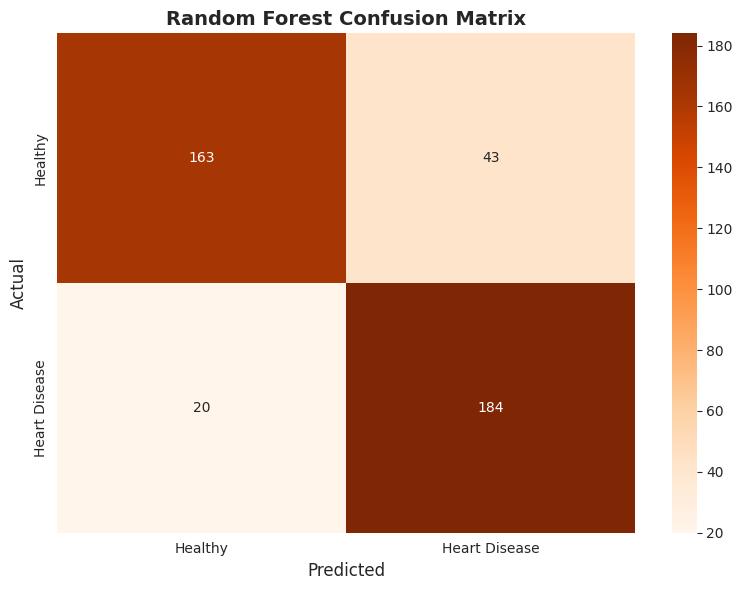

In [52]:
# Evaluation
print("\n📋 Random Forest Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Heart Disease']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "="*60)


⭐ Feature Importance (Random Forest):
 Feature  Importance
    thal    0.148883
      ca    0.142984
      cp    0.141893
 thalach    0.125332
   exang    0.109618
 oldpeak    0.107786
     age    0.068270
   slope    0.044714
trestbps    0.038652
    chol    0.038152
     sex    0.020596
 restecg    0.010446
     fbs    0.002674


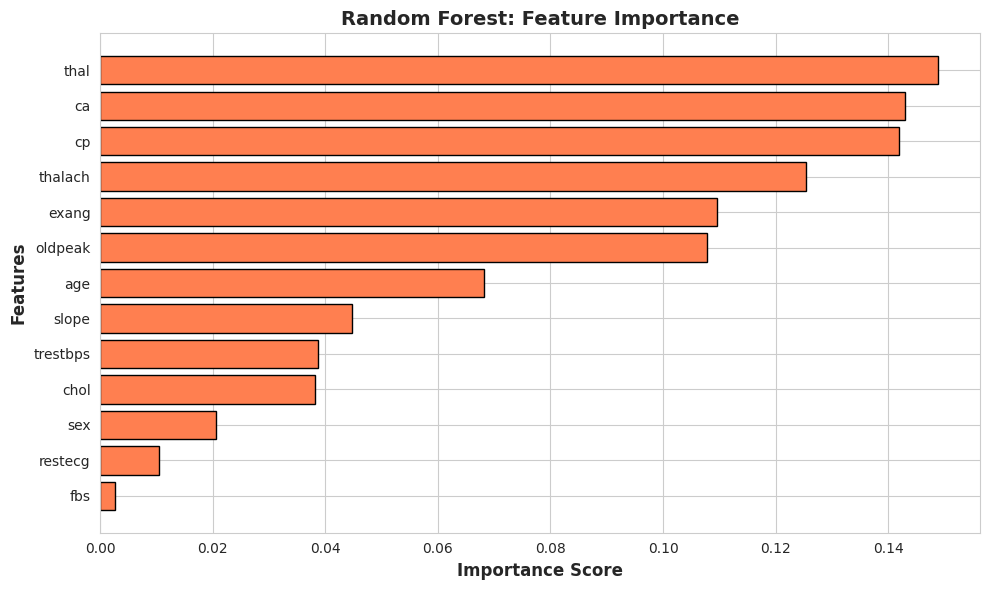


💡 Random Forest importance is more reliable!
   (Average of 120 trees)



In [53]:
# Feature Importance
print("\n⭐ Feature Importance (Random Forest):")
print("=" * 60)

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'],
         color='coral', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Random Forest: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n💡 Random Forest importance is more reliable!")
print("   (Average of 120 trees)")
print("\n" + "="*60)

## Model Comparison and Final Result

In [54]:
# Compare all models
print("\n🏆 FINAL MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [knn_accuracy, dt_accuracy, rf_accuracy],
    'Accuracy %': [f"{knn_accuracy*100:.2f}%", f"{dt_accuracy*100:.2f}%", f"{rf_accuracy*100:.2f}%"]
})

comparison = comparison.sort_values('Accuracy', ascending=False)
print("\n" + comparison.to_string(index=False))

best_model = comparison.iloc[0]['Model']
best_acc = comparison.iloc[0]['Accuracy']

print(f"\n🥇 WINNER: {best_model}")
print(f"   Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print("\n" + "="*60)


🏆 FINAL MODEL COMPARISON

        Model  Accuracy Accuracy %
          KNN  0.960976     96.10%
Decision Tree  0.863415     86.34%
Random Forest  0.846341     84.63%

🥇 WINNER: KNN
   Accuracy: 0.9610 (96.10%)



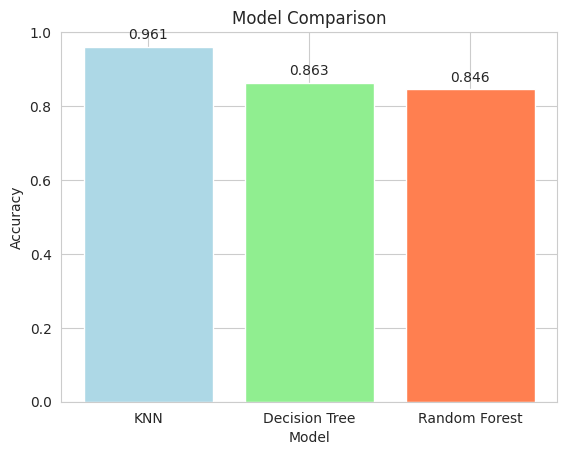

In [55]:
# Visual Comparison
plt.bar(comparison['Model'], comparison['Accuracy'], color=['lightblue', 'lightgreen', 'coral'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])

# Add values on bars
for i, acc in enumerate(comparison['Accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')

plt.show()